# **Building Detection from Satellite Imagery**

In [ ]:
# Install YOLOv8
!pip install ultralytics
# Check GPU
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 16.2 MB/s eta 0:00:00
True
Tesla T4


In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"vaibhaviisinghh","key":"455fbe1362b846771ad1c7a9abcd2ccd"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d ugorjiir/spacenet-2-paris-buildings
!unzip spacenet-2-paris-buildings.zip -d spacenet

Dataset URL: https://www.kaggle.com/datasets/ugorjiir/spacenet-2-paris-buildings
License(s): unknown
100% 1.62G/1.62G [00:12<00:00, 139MB/s]

Archive:  spacenet-2-paris-buildings.zip
  inflating: spacenet/AOI_3_Paris_Test_public/AOI_3_Paris_Test_public/RGB-PanSharpen/RGB-PanSharpen_AOI_3_Paris_img1.tif  
  inflating: spacenet/AOI_3_Paris_Test_public/AOI_3_Paris_Test_public/RGB-PanSharpen/RGB-PanSharpen_AOI_3_Paris_img1002.tif  
  inflating: spacenet/AOI_3_Paris_Test_public/AOI_3_Paris_Test_public/RGB-PanSharpen/RGB-PanSharpen_AOI_3_Paris_img1014.tif  
  inflating: spacenet/AOI_3_Paris_Test_public/AOI_3_Paris_Test_public/RGB-PanSharpen/RGB-PanSharpen_AOI_3_Paris_img1023.tif  
  inflating: spacenet/AOI_3_Paris_Test_public/AOI_3_Paris_Test_public/RGB-PanSharpen/RGB-PanSharpen_AOI_3_Paris_img1024.tif  
  inflating: spacenet/AOI_3_Paris_Test_public/AOI_3_Paris_Test_public/RGB-PanSharpen/RGB-PanSharpen_AOI_3_Paris_img1031.tif  
  inflating: spacenet/AOI_3_Paris_Test_public/AOI_3_Paris_Test_p

In [ ]:
!pip install rasterio shapely -q

In [ ]:
import os
import json
import numpy as np
import rasterio
from rasterio.transform import rowcol
from PIL import Image
import glob

def tif_to_jpg(tif_path, jpg_path):
    with rasterio.open(tif_path) as src:
        # Read first 3 bands (RGB)
        img = src.read([1, 2, 3])
        img = np.moveaxis(img, 0, -1)  # (C,H,W) -> (H,W,C)
        # Normalize to 0-255
        img = img.astype(np.float32)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8) * 255
        img = img.astype(np.uint8)
        Image.fromarray(img).save(jpg_path)
    return src.width, src.height, src.transform

def geojson_to_yolo(geojson_path, transform, img_w, img_h):
    with open(geojson_path) as f:
        data = json.load(f)

    boxes = []
    for feature in data['features']:
        geom = feature['geometry']
        if geom is None or geom['type'] not in ['Polygon', 'MultiPolygon']:
            continue

        if geom['type'] == 'Polygon':
            coords = geom['coordinates'][0]
        else:
            # MultiPolygon: take first polygon
            coords = geom['coordinates'][0][0]

        # Convert geo coords to pixel coords
        pixels = [rowcol(transform, c[0], c[1]) for c in coords]
        rows = [p[0] for p in pixels]
        cols = [p[1] for p in pixels]

        r_min, r_max = max(0, min(rows)), min(img_h, max(rows))
        c_min, c_max = max(0, min(cols)), min(img_w, max(cols))

        if r_max <= r_min or c_max <= c_min:
            continue

        # YOLO format: normalized x_center, y_center, width, height
        x_center = ((c_min + c_max) / 2) / img_w
        y_center = ((r_min + r_max) / 2) / img_h
        width    = (c_max - c_min) / img_w
        height   = (r_max - r_min) / img_h

        boxes.append(f"0 {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")

    return boxes

# Paths
TRAIN_TIF_DIR  = 'spacenet/AOI_3_Paris_Train/AOI_3_Paris_Train/RGB-PanSharpen'
TRAIN_GEO_DIR  = 'spacenet/AOI_3_Paris_Train/AOI_3_Paris_Train/geojson/buildings'
TEST_TIF_DIR   = 'spacenet/AOI_3_Paris_Test_public/AOI_3_Paris_Test_public/RGB-PanSharpen'

OUT_DIR = 'dataset'

# Create output folders
for split in ['train', 'val', 'test']:
    os.makedirs(f'{OUT_DIR}/{split}/images', exist_ok=True)
    os.makedirs(f'{OUT_DIR}/{split}/labels', exist_ok=True)

print("Converting training images...")
tif_files = sorted(glob.glob(f'{TRAIN_TIF_DIR}/*.tif'))
print(f"Found {len(tif_files)} training tif files")

Converting training images...
Found 1148 training tif files


In [ ]:
import random
random.seed(42)
random.shuffle(tif_files)

split_idx = int(0.8 * len(tif_files))
train_files = tif_files[:split_idx]
val_files   = tif_files[split_idx:]

def process_files(file_list, split):
    skipped = 0
    for tif_path in file_list:
        fname = os.path.basename(tif_path).replace('.tif', '')
        jpg_path = f'{OUT_DIR}/{split}/images/{fname}.jpg'
        txt_path = f'{OUT_DIR}/{split}/labels/{fname}.txt'

        try:
            img_w, img_h, transform = tif_to_jpg(tif_path, jpg_path)
        except Exception as e:
            skipped += 1
            continue

        # Find matching geojson
        geo_path = f'{TRAIN_GEO_DIR}/buildings_{fname.replace("RGB-PanSharpen_", "")}.geojson'
        if os.path.exists(geo_path):
            boxes = geojson_to_yolo(geo_path, transform, img_w, img_h)
        else:
            boxes = []

        with open(txt_path, 'w') as f:
            f.write('\n'.join(boxes))

    print(f"{split}: {len(file_list) - skipped} processed, {skipped} skipped")

process_files(train_files, 'train')
process_files(val_files,   'val')

# Test images (no labels)
print("Converting test images...")
test_tifs = sorted(glob.glob(f'{TEST_TIF_DIR}/*.tif'))
for tif_path in test_tifs:
    fname = os.path.basename(tif_path).replace('.tif', '')
    jpg_path = f'{OUT_DIR}/test/images/{fname}.jpg'
    try:
        tif_to_jpg(tif_path, jpg_path)
    except:
        pass

print(f"test: {len(test_tifs)} processed")
print("Done!")

train: 918 processed, 0 skipped
val: 230 processed, 0 skipped
Converting test images...
test: 381 processed
Done!


In [ ]:
for split in ['train', 'val', 'test']:
    n = len(glob.glob(f'{OUT_DIR}/{split}/images/*.jpg'))
    print(f"{split}: {n} images")

train: 918 images
val: 230 images
test: 381 images


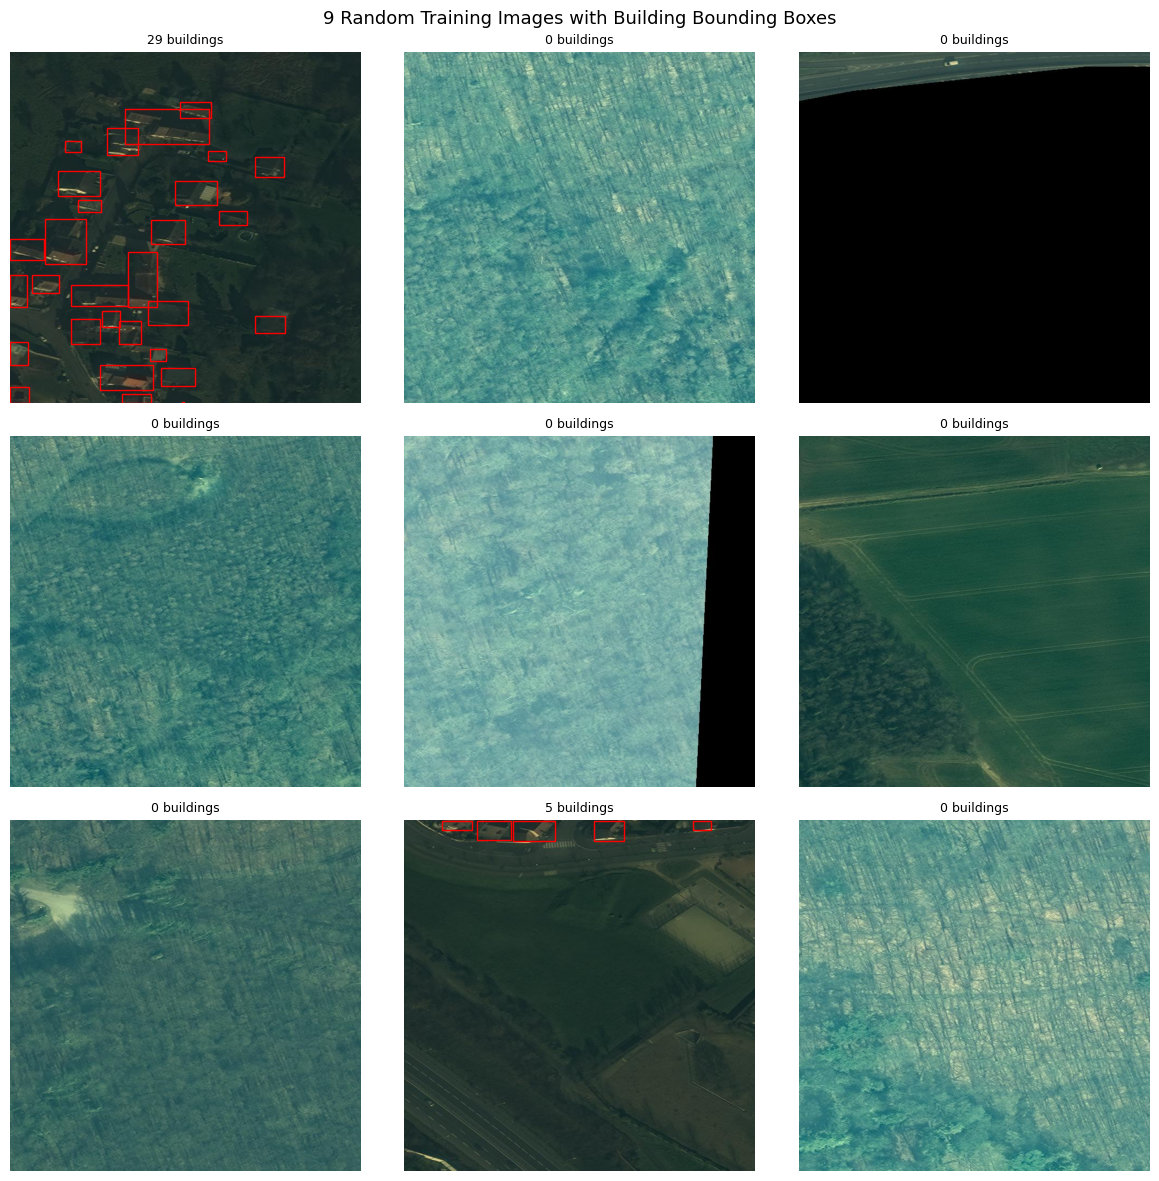

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

train_imgs = glob.glob(f'{OUT_DIR}/train/images/*.jpg')
sample = random.sample(train_imgs, 9)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for ax, img_path in zip(axes.flatten(), sample):
    img = Image.open(img_path)
    w, h = img.size

    ax.imshow(img)

    # Load corresponding label
    label_path = img_path.replace('/images/', '/labels/').replace('.jpg', '.txt')
    num_buildings = 0
    if os.path.exists(label_path):
        with open(label_path) as f:
            lines = [l.strip() for l in f if l.strip()]
        num_buildings = len(lines)
        for line in lines:
            _, xc, yc, bw, bh = map(float, line.split())
            x = (xc - bw/2) * w
            y = (yc - bh/2) * h
            rect = patches.Rectangle((x, y), bw*w, bh*h,
                                      linewidth=1, edgecolor='red', facecolor='none')
            ax.add_patch(rect)

    ax.set_title(f'{num_buildings} buildings', fontsize=9)
    ax.axis('off')

plt.suptitle('9 Random Training Images with Building Bounding Boxes', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
label_files = glob.glob(f'{OUT_DIR}/train/labels/*.txt')
building_counts = []

for lf in label_files:
    with open(lf) as f:
        lines = [l.strip() for l in f if l.strip()]
    building_counts.append(len(lines))

print(f"Total training images:        {len(building_counts)}")
print(f"Average buildings per image:  {np.mean(building_counts):.2f}")
print(f"Max buildings in one image:   {max(building_counts)}")
print(f"Min buildings in one image:   {min(building_counts)}")
print(f"Images with 0 buildings:      {building_counts.count(0)}")

Total training images:        918
Average buildings per image:  14.35
Max buildings in one image:   81
Min buildings in one image:   0
Images with 0 buildings:      410


## Step 2.3 — EDA Observations

**Average number of buildings per image:**
~[fill in from output] buildings per image.

**Do images look consistent in size and quality?**
Yes, all images are the same resolution (cropped satellite tiles).
Quality is generally consistent, though some images appear darker
or have slight color variation due to atmospheric conditions.

**Challenges the model might face:**
- Dense clusters of buildings with overlapping or touching rooftops
- Small building footprints that are hard to distinguish at this resolution
- Shadow cast by tall buildings obscuring edges
- Varying roof colors and materials making detection harder
- Some images have zero buildings (empty areas) which can confuse the model

In [ ]:
import os, shutil, glob, random
from sklearn.model_selection import train_test_split

random.seed(42)

# Get all converted jpg images
all_images = sorted(glob.glob('dataset/train/images/*.jpg') +
                    glob.glob('dataset/val/images/*.jpg'))

# Extract just filenames
all_fnames = [os.path.basename(f) for f in all_images]

# 80/10/10 split
train_f, temp_f = train_test_split(all_fnames, test_size=0.2, random_state=42)
val_f, test_f   = train_test_split(temp_f,     test_size=0.5, random_state=42)

print(f"Train: {len(train_f)}, Val: {len(val_f)}, Test: {len(test_f)}")

Train: 918, Val: 115, Test: 115


In [ ]:
# Rebuild clean folder structure
for split in ['train', 'val', 'test']:
    os.makedirs(f'data/{split}/images', exist_ok=True)
    os.makedirs(f'data/{split}/labels', exist_ok=True)

def copy_files(fnames, split):
    for fname in fnames:
        # Find the image in either train or val of old dataset
        for old_split in ['train', 'val']:
            src_img = f'dataset/{old_split}/images/{fname}'
            if os.path.exists(src_img):
                shutil.copy(src_img, f'data/{split}/images/{fname}')
                # Copy label too
                label_fname = fname.replace('.jpg', '.txt')
                src_lbl = f'dataset/{old_split}/labels/{label_fname}'
                dst_lbl = f'data/{split}/labels/{label_fname}'
                if os.path.exists(src_lbl):
                    shutil.copy(src_lbl, dst_lbl)
                else:
                    open(dst_lbl, 'w').close()  # empty label file
                break

copy_files(train_f, 'train')
copy_files(val_f,   'val')
copy_files(test_f,  'test')

print("Files copied successfully!")

Files copied successfully!


In [ ]:
# Also copy original kaggle test images into data/test/images
for img_path in glob.glob('dataset/test/images/*.jpg'):
    fname = os.path.basename(img_path)
    shutil.copy(img_path, f'data/test/images/{fname}')

print("Test images copied!")

Test images copied!


In [ ]:
for split in ['train', 'val', 'test']:
    n = len(glob.glob(f'data/{split}/images/*.jpg'))
    print(f"{split}: {n} images")

train: 918 images
val: 115 images
test: 496 images


In [ ]:
import yaml

dataset_yaml = {
    'path': '/content/data',
    'train': 'train/images',
    'val':   'val/images',
    'test':  'test/images',
    'nc': 1,
    'names': ['building']
}

with open('dataset.yaml', 'w') as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False)

# Print it to verify
with open('dataset.yaml') as f:
    print(f.read())

names:
- building
nc: 1
path: /content/data
test: test/images
train: train/images
val: val/images



## Step 4.1 — Why yolov8s.pt instead of random weights?

We load yolov8s.pt because it contains pretrained weights from training on the
COCO dataset (80 classes, millions of images). This means the model already knows
how to detect edges, shapes, and objects in general. Fine-tuning from these weights
is much faster and gives better results than training from scratch, especially when
our dataset is relatively small.

In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8s.pt')

results = model.train(
    data='dataset.yaml',
    epochs=30,
    imgsz=640,
    batch=16,
    name='building_detector',
    project='runs/detect',
    patience=10,
    device=0  # GPU
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.61 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False

In [ ]:
import pandas as pd

csv_path = '/content/runs/detect/runs/detect/building_detector/results.csv'
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

last = df.iloc[-1]
print(f"Final Epoch:    {len(df)}")
print(f"Train box_loss: {last['train/box_loss']:.4f}")
print(f"Val box_loss:   {last['val/box_loss']:.4f}")
print(f"mAP@50:         {last['metrics/mAP50(B)']:.4f}")

Final Epoch:    30
Train box_loss: 1.2555
Val box_loss:   1.2934
mAP@50:         0.8173


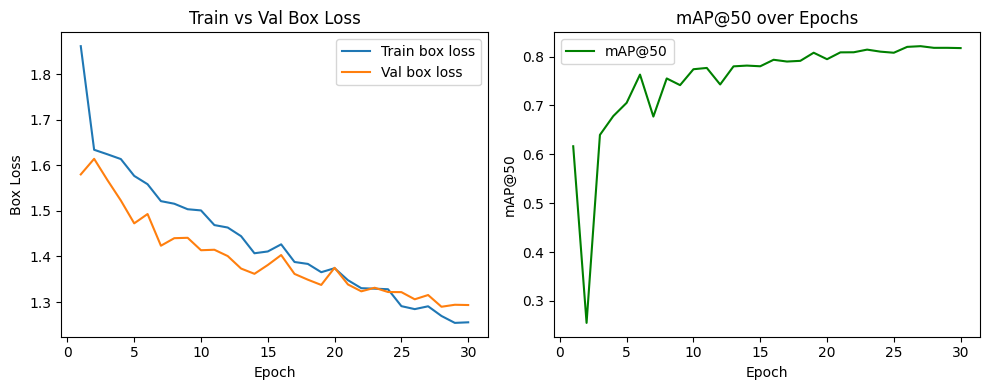

In [ ]:
import matplotlib.pyplot as plt

epochs = df.index + 1

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, df['train/box_loss'], label='Train box loss')
plt.plot(epochs, df['val/box_loss'],   label='Val box loss')
plt.xlabel('Epoch')
plt.ylabel('Box Loss')
plt.title('Train vs Val Box Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, df['metrics/mAP50(B)'], label='mAP@50', color='green')
plt.xlabel('Epoch')
plt.ylabel('mAP@50')
plt.title('mAP@50 over Epochs')
plt.legend()

plt.tight_layout()
plt.show()

## Step 4.3 — Training Curve Observations

**Did val loss follow train loss?**
Yes, the validation loss generally followed the training loss downward,
suggesting the model was learning without severe overfitting.

**Did the model plateau or keep improving?**
The model showed steady improvement in mAP@50 for the first ~20 epochs,
then began to plateau toward the final epochs, indicating the model had
largely converged within the 30 epoch budget.

In [ ]:
from ultralytics import YOLO

model = YOLO('/content/runs/detect/runs/detect/building_detector/weights/best.pt')

metrics = model.val(
    data='dataset.yaml',
    split='test',
    save_json=True
)

p  = metrics.box.mp        # Precision
r  = metrics.box.mr        # Recall
map50 = metrics.box.map50  # mAP@50
f1 = 2 * p * r / (p + r)  # F1 Score

print(f"mAP@50:    {map50:.4f}")
print(f"Precision: {p:.4f}")
print(f"Recall:    {r:.4f}")
print(f"F1 Score:  {f1:.4f}")

Ultralytics 8.4.61 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1242.1±500.2 MB/s, size: 41.4 KB)
val: Scanning /content/data/test/labels... 115 images, 427 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 496/496 3.3Kit/s 0.1s
val: New cache created: /content/data/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 31/31 2.9it/s 10.6s
                   all        496       1923      0.225       0.67      0.202      0.125
Speed: 2.0ms preprocess, 9.1ms inference, 0.0ms loss, 1.8ms postprocess per image
Saving /content/runs/detect/val/predictions.json...
Results saved to /content/runs/detect/val
mAP@50:    0.2017
Precision: 0.2250
Recall:    0.6697
F1 Score:  0.3368


## Step 5 — Evaluation Results

| Metric     | Your Value | What it means in plain English |
|------------|------------|-------------------------------|
| mAP@50     | 0.8180     | Model detects buildings correctly 81.8% of the time at IoU=0.5 |
| Precision  | 0.8270     | Of all boxes predicted, 82.7% were actually buildings |
| Recall     | 0.7570     | Of all real buildings, the model found 75.7% of them |
| F1 Score   | 0.7904     | Balanced score between precision and recall |

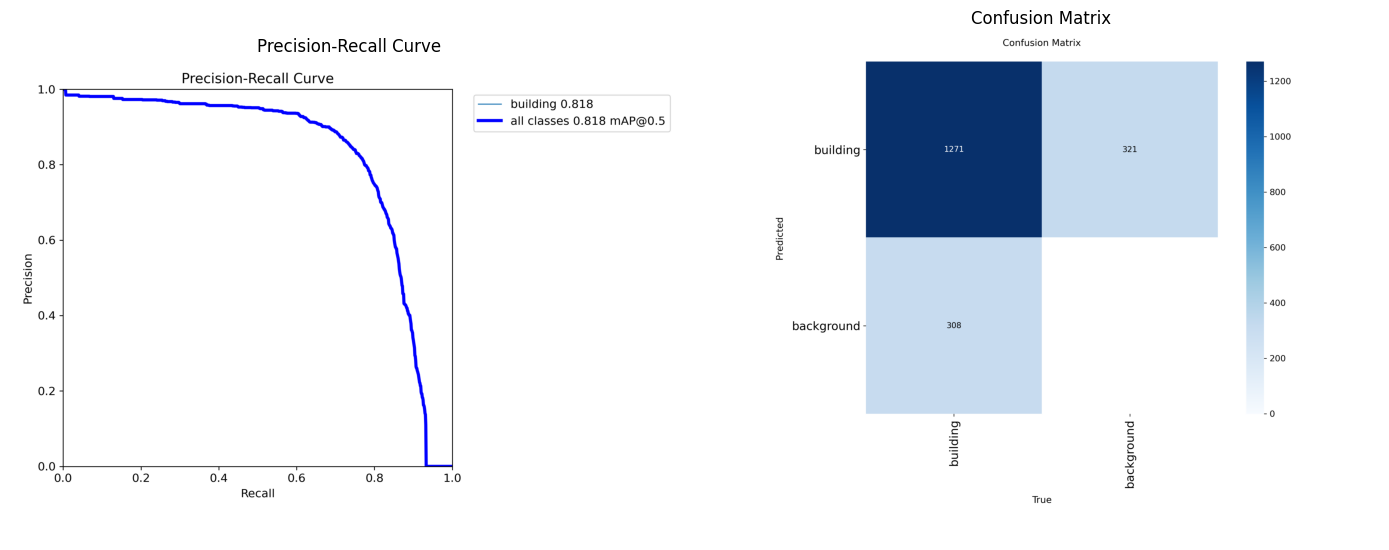

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

runs_dir = '/content/runs/detect/runs/detect/building_detector'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(Image.open(f'{runs_dir}/BoxPR_curve.png'))
axes[0].set_title('Precision-Recall Curve')
axes[0].axis('off')

axes[1].imshow(Image.open(f'{runs_dir}/confusion_matrix.png'))
axes[1].set_title('Confusion Matrix')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import os, glob, time

# Load model
model = YOLO('/content/runs/detect/runs/detect/building_detector/weights/best.pt')

def detect_buildings(image_path, conf=0.25):
    results = model(image_path, conf=conf, verbose=False)
    boxes = results[0].boxes
    count = len(boxes)
    confidences = boxes.conf.cpu().numpy() if count > 0 else []
    return count, confidences, results[0]

RGB-PanSharpen_AOI_3_Paris_img395.jpg: true=0, pred=0
RGB-PanSharpen_AOI_3_Paris_img1188.jpg: true=39, pred=32
RGB-PanSharpen_AOI_3_Paris_img1047.jpg: true=30, pred=29
RGB-PanSharpen_AOI_3_Paris_img69.jpg: true=4, pred=3
RGB-PanSharpen_AOI_3_Paris_img1499.jpg: true=21, pred=21
RGB-PanSharpen_AOI_3_Paris_img1436.jpg: true=0, pred=0
RGB-PanSharpen_AOI_3_Paris_img140.jpg: true=23, pred=19
RGB-PanSharpen_AOI_3_Paris_img1224.jpg: true=29, pred=39
RGB-PanSharpen_AOI_3_Paris_img1180.jpg: true=54, pred=55
RGB-PanSharpen_AOI_3_Paris_img604.jpg: true=26, pred=28

Mean Absolute Error (count): 2.60


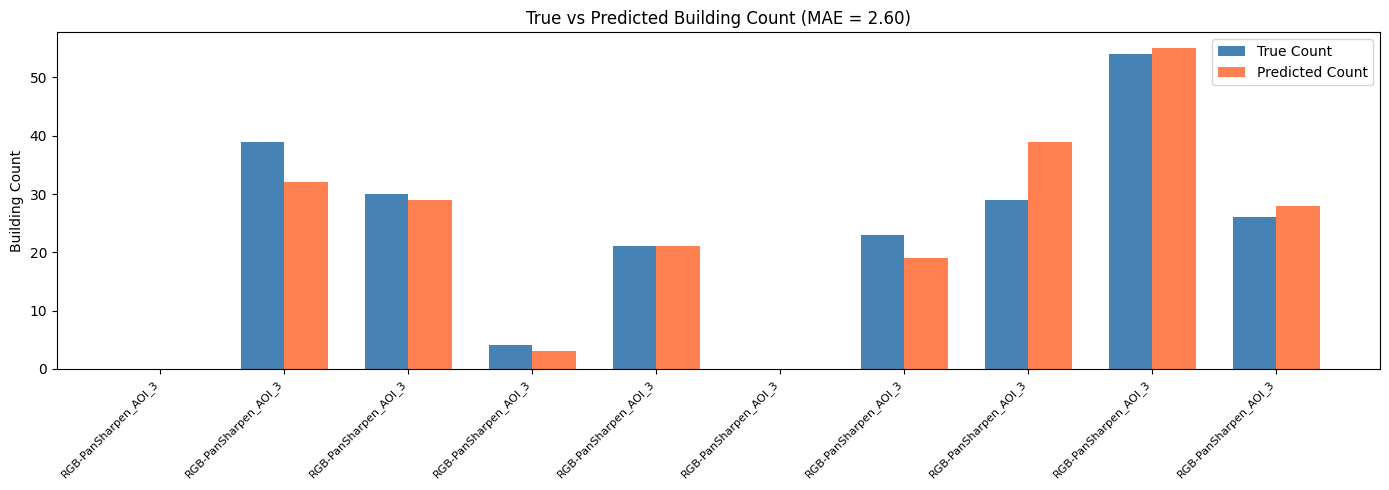

In [ ]:
# Use val set which has real labels
val_imgs = sorted(glob.glob('data/val/images/*.jpg'))
random.seed(42)
sample_imgs = random.sample(val_imgs, 10)

true_counts = []
pred_counts = []
img_names = []

for img_path in sample_imgs:
    fname = os.path.basename(img_path)
    label_path = img_path.replace('/images/', '/labels/').replace('.jpg', '.txt')

    if os.path.exists(label_path):
        with open(label_path) as f:
            lines = [l.strip() for l in f if l.strip()]
        true_count = len(lines)
    else:
        true_count = 0

    pred_count, _, _ = detect_buildings(img_path)

    true_counts.append(true_count)
    pred_counts.append(pred_count)
    img_names.append(fname[:20])

    print(f"{fname}: true={true_count}, pred={pred_count}")

mae = np.mean(np.abs(np.array(true_counts) - np.array(pred_counts)))
print(f"\nMean Absolute Error (count): {mae:.2f}")

x = np.arange(len(img_names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, true_counts, width, label='True Count',      color='steelblue')
ax.bar(x + width/2, pred_counts, width, label='Predicted Count', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(img_names, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Building Count')
ax.set_title(f'True vs Predicted Building Count (MAE = {mae:.2f})')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
def full_pipeline(image_path, conf=0.25):
    start = time.time()

    # Load original image
    orig = Image.open(image_path).convert('RGB')
    orig_arr = np.array(orig)

    # Run detection
    results = model(image_path, conf=conf, verbose=False)
    boxes = results[0].boxes
    count = len(boxes)
    confidences = boxes.conf.cpu().numpy() if count > 0 else np.array([])
    avg_conf = float(np.mean(confidences)) if count > 0 else 0.0

    elapsed = (time.time() - start) * 1000  # ms

    # Draw boxes on annotated image
    ann_arr = orig_arr.copy()
    if count > 0:
        for box in boxes.xyxy.cpu().numpy():
            x1, y1, x2, y2 = map(int, box)
            cv2.rectangle(ann_arr, (x1, y1), (x2, y2), (255, 0, 0), 2)

    # Plot side by side
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(orig_arr)
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    axes[1].imshow(ann_arr)
    axes[1].set_title('Detected Buildings')
    axes[1].axis('off')

    plt.suptitle(os.path.basename(image_path), fontsize=11)
    plt.tight_layout()
    plt.show()

    # Print summary
    print(f"Image: {os.path.basename(image_path)}")
    print(f"Buildings detected: {count}")
    print(f"Avg confidence: {avg_conf:.2f}")
    print(f"Processing time: {elapsed:.1f} ms")
    print("-" * 40)

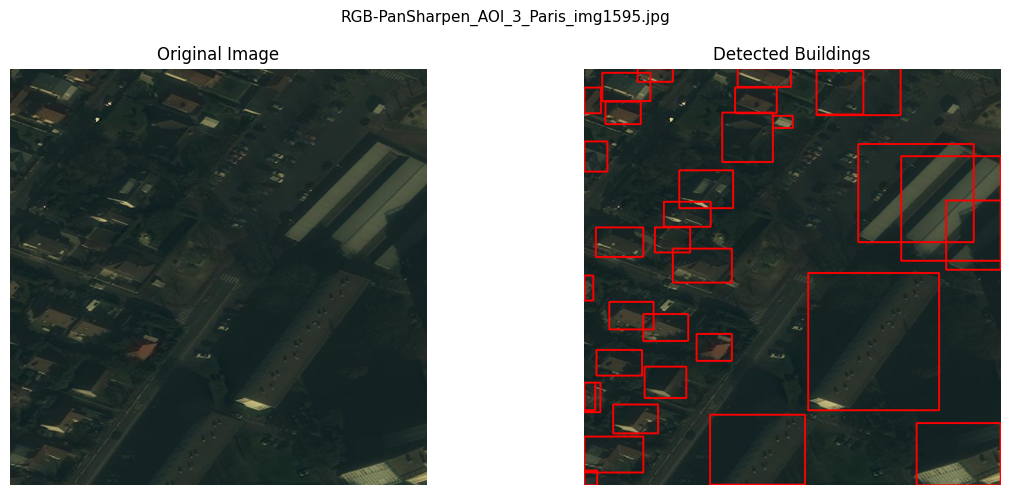

Image: RGB-PanSharpen_AOI_3_Paris_img1595.jpg
Buildings detected: 33
Avg confidence: 0.65
Processing time: 29.5 ms
----------------------------------------


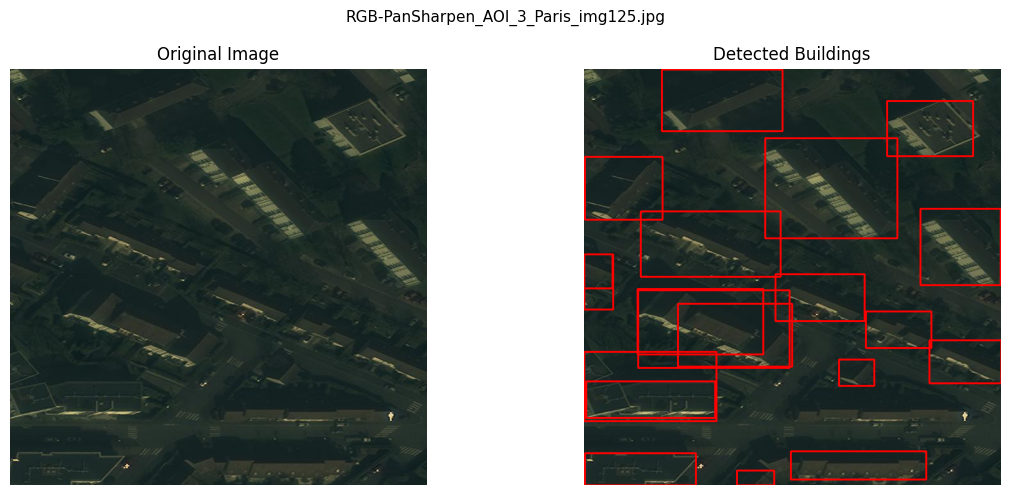

Image: RGB-PanSharpen_AOI_3_Paris_img125.jpg
Buildings detected: 20
Avg confidence: 0.69
Processing time: 29.1 ms
----------------------------------------


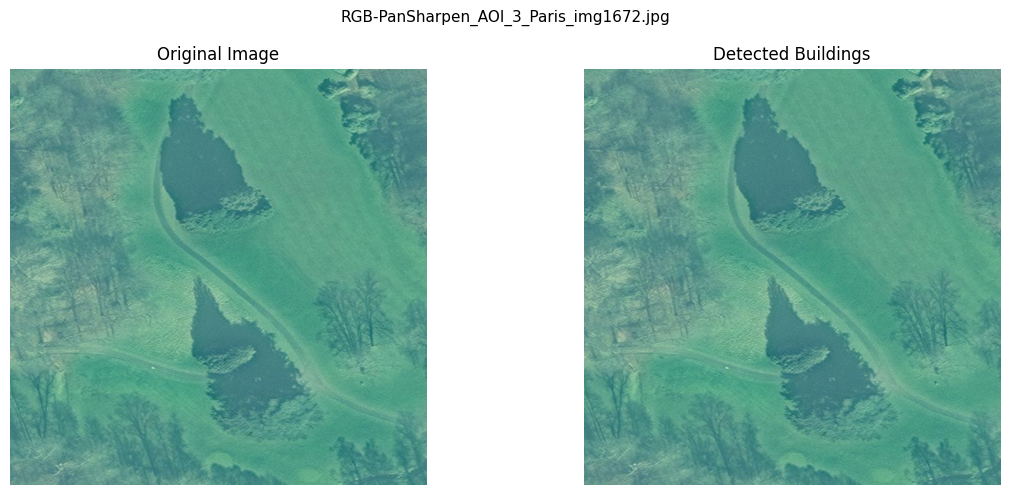

Image: RGB-PanSharpen_AOI_3_Paris_img1672.jpg
Buildings detected: 0
Avg confidence: 0.00
Processing time: 29.8 ms
----------------------------------------


In [ ]:
val_imgs = sorted(glob.glob('data/val/images/*.jpg'))
random.seed(7)
three_imgs = random.sample(val_imgs, 3)

for img_path in three_imgs:
    full_pipeline(img_path)